# Baseline (w/out `Shape__Length`): predict `risk_proxy`

**Target**: `risk_proxy` (still excludes `Normalized_Length` and `PHASE_WEIGHT` as inputs to avoid definitional leakage).


## 1. Load modeling dataset

`construction_with_risk_proxy.csv` from [risk-proxy.ipynb](../../analysis/risk-proxy.ipynb).


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split


def find_modeling_csv(name: str = "construction_with_risk_proxy.csv") -> Path:
    """Resolve CSV whether the kernel cwd is repo root, analysis/, or src/models/."""
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        for sub in ("data/processed", "src/data/processed"):
            p = base / sub / name
            if p.is_file():
                return p
    raise FileNotFoundError(
        f"Could not find {name} under data/processed or src/data/processed "
        "(from cwd upward). Run analysis/risk-proxy.ipynb through the CSV export cell."
    )


csv_path = find_modeling_csv()
construction_df = pd.read_csv(csv_path)
print(f"Loaded rows={len(construction_df):,} from {csv_path.resolve()}")


Loaded rows=6,942 from /home/trevor/repos/CAP_3764_2026_Spring_Team_1/src/data/processed/construction_with_risk_proxy.csv


## 2. Modeling frame

In [4]:
df_model = construction_df.copy()
df_model["WPWKMIXN"] = df_model["WPWKMIXN"].astype(str).str.strip()


## 3. Reduce work-mix categories

Same as the full baseline: top *k* by frequency, remainder → `"Other"`.


In [5]:
TOP_K_WORK_MIX = 12

vc = df_model["WPWKMIXN"].value_counts()
top = set(vc.head(TOP_K_WORK_MIX).index)
# Reduce work-mix categories
df_model["work_mix_reduced"] = np.where(
    df_model["WPWKMIXN"].isin(top),
    df_model["WPWKMIXN"],
    "Other",
)
# Display reduced work-mix cardinality
print("Reduced work-mix cardinality:", df_model["work_mix_reduced"].nunique())
print(df_model["work_mix_reduced"].value_counts().head(15))


Reduced work-mix cardinality: 13
work_mix_reduced
RESURFACING             1833
Other                   1125
ADD LANES & RECONSTR     882
BRIDGE-REPLACE AND A     638
INTERCHANGE RAMP (NE     585
ITS FREEWAY MANAGEME     476
RIGID PAVEMENT RECON     286
RIGID PAVEMENT REHAB     286
INTERSECTION IMPROVE     250
PEDESTRIAN SAFETY IM     158
FLEXIBLE PAVEMENT RE     148
INTERCHANGE - ADD LA     140
BIKE PATH/TRAIL          135
Name: count, dtype: int64


## 4. Feature matrix and target

**No `Shape__Length`**: numeric `FISCALYR` only, plus one-hot `WPPHAZTP_DESC` and `work_mix_reduced` (`drop_first=True`).


In [6]:
y = df_model["risk_proxy"]

num = df_model[["FISCALYR"]].copy()
# 1-hot encoding for categoricals ("WPPHAZTP_DESC", "work_mix_reduced")
cat = pd.get_dummies(
    df_model[["WPPHAZTP_DESC", "work_mix_reduced"]],
    columns=["WPPHAZTP_DESC", "work_mix_reduced"],
    drop_first=True,
    dtype=float,
)
X = pd.concat([num, cat], axis=1)
# Display feature matrix
print("Feature shape:", X.shape)
print("Columns:", list(X.columns))
X.head()


Feature shape: (6942, 16)
Columns: ['FISCALYR', 'WPPHAZTP_DESC_Construction Completed', 'WPPHAZTP_DESC_Contract Executed', 'WPPHAZTP_DESC_Pre-Construction', 'work_mix_reduced_BIKE PATH/TRAIL', 'work_mix_reduced_BRIDGE-REPLACE AND A', 'work_mix_reduced_FLEXIBLE PAVEMENT RE', 'work_mix_reduced_INTERCHANGE - ADD LA', 'work_mix_reduced_INTERCHANGE RAMP (NE', 'work_mix_reduced_INTERSECTION IMPROVE', 'work_mix_reduced_ITS FREEWAY MANAGEME', 'work_mix_reduced_Other', 'work_mix_reduced_PEDESTRIAN SAFETY IM', 'work_mix_reduced_RESURFACING', 'work_mix_reduced_RIGID PAVEMENT RECON', 'work_mix_reduced_RIGID PAVEMENT REHAB']


,FISCALYR,WPPHAZTP_DESC_Construction Completed,WPPHAZTP_DESC_Contract Executed,WPPHAZTP_DESC_Pre-Construction,work_mix_reduced_BIKE PATH/TRAIL,work_mix_reduced_BRIDGE-REPLACE AND A,work_mix_reduced_FLEXIBLE PAVEMENT RE,work_mix_reduced_INTERCHANGE - ADD LA,work_mix_reduced_INTERCHANGE RAMP (NE,work_mix_reduced_INTERSECTION IMPROVE,work_mix_reduced_ITS FREEWAY MANAGEME,work_mix_reduced_Other,work_mix_reduced_PEDESTRIAN SAFETY IM,work_mix_reduced_RESURFACING,work_mix_reduced_RIGID PAVEMENT RECON,work_mix_reduced_RIGID PAVEMENT REHAB
0,2025,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2023,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Train / test split and Random Forest

Same hyperparameters as `baseline_risk_proxy.ipynb` for a direct comparison.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)   
mape = mean_absolute_percentage_error(y_test, y_pred)
# Display test metrics
print(f"Test MSE:  {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test R²:   {r2:.4f}")
print(f"Test MAE:  {mae:.6f}")
print(f"Test MAPE: {mape:.4f}")


Test MSE:  0.007055
Test RMSE: 0.083996
Test R²:   0.1416
Test MAE:  0.045997
Test MAPE: 5.8019


## 6. Feature importances


In [8]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
# Display feature scores
feat_imp


FISCALYR                                 0.176070
WPPHAZTP_DESC_Construction Completed     0.118786
work_mix_reduced_ITS FREEWAY MANAGEME    0.089187
WPPHAZTP_DESC_Pre-Construction           0.086400
work_mix_reduced_FLEXIBLE PAVEMENT RE    0.071851
work_mix_reduced_INTERCHANGE RAMP (NE    0.061625
work_mix_reduced_BRIDGE-REPLACE AND A    0.060904
work_mix_reduced_RIGID PAVEMENT REHAB    0.057094
work_mix_reduced_Other                   0.047899
work_mix_reduced_INTERSECTION IMPROVE    0.039551
work_mix_reduced_RESURFACING             0.037848
work_mix_reduced_INTERCHANGE - ADD LA    0.037672
work_mix_reduced_PEDESTRIAN SAFETY IM    0.035683
work_mix_reduced_RIGID PAVEMENT RECON    0.034203
WPPHAZTP_DESC_Contract Executed          0.024471
work_mix_reduced_BIKE PATH/TRAIL         0.020756
dtype: float64

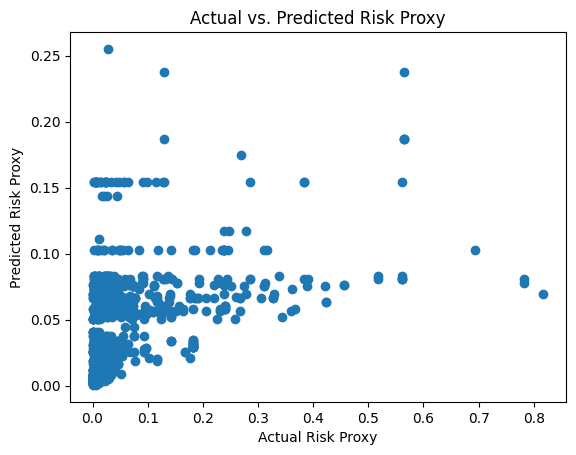

In [9]:
# Plot results
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Risk Proxy")
plt.ylabel("Predicted Risk Proxy")
plt.title("Actual vs. Predicted Risk Proxy")
plt.show()


### Interpretation

The reduced model (excluding Shape_Length) shows a significant drop in performance ($R^2 \approx 0.14$) 
- Results confirm that most of the variance in `risk_proxy` is driven by segment length.

This result isolates the contribution of secondary features such as fiscal year, construction phase, and work type. 
- While these variables provide some predictive signal, their explanatory power is limited without direct exposure measures.

### Conclusion
> Reinforcement that `risk_proxy` is primarily a function of project scale $\rightarrow$ contextual metadata alone is insufficient to accurately approximate project impact.